# Exploratory Data Analysis: ZenML LLMOps Dataset

This notebook explores the [ZenML LLMOps dataset](https://huggingface.co/datasets/zenml/llmops-database) to understand its structure and inform the design of an automated AI newsletter generator.

## Key Findings Summary

| Aspect | Finding |
|--------|---------|
| **Dataset Size** | 1,418 items, 13 columns |
| **Date Range** | July 2024 – January 2026 |
| **Data Quality** | Excellent - minimal missing values |
| **Weekly Items** | Median 14, Mean 23 (highly variable) |
| **Short Summary** | ~100 words (ideal for newsletter) |
| **Top Industry** | Tech (dominant), followed by E-commerce, Finance |
| **Top Techniques** | Prompt engineering, error handling, semantic search |

---

## Data Loading

In [1]:
import polars as pl

df = pl.read_parquet("hf://datasets/zenml/llmops-database/data/train-00000-of-00001.parquet")
df

created_at,title,industry,year,source_url,company,application_tags,tools_tags,extra_tags,techniques_tags,short_summary,full_summary,webflow_url
str,str,str,i64,str,str,str,str,str,str,str,str,str
"""2024-07-10T14:21:00.000Z""","""Building a Scalable Retriever-…","""Tech""",2024,"""https://blog.malt.engineering/…","""malt""","""structured_output,realtime_app…","""kubernetes,monitoring,scaling,…","""recommenders,rerankers,vector …","""embeddings,semantic_search,vec…","""Malt, a freelancer marketplace…","""# Malt: Building a Scalable Re…","""https://www.zenml.io/llmops-da…"
"""2024-08-06T12:08:00.000Z""","""Optimizing Email Engagement Us…","""Tech""",2023,"""https://engblog.nextdoor.com/l…","""nextdoor""","""structured_output,realtime_app…","""monitoring,cache,reliability,s…","""chatgpt,prompt engineering,rej…","""fine_tuning,prompt_engineering…","""Nextdoor faced the challenge t…","""# Nextdoor: Optimizing Email E…","""https://www.zenml.io/llmops-da…"
"""2024-07-31T13:53:00.000Z""","""Medical AI Assistant for Battl…","""Healthcare""",2023,"""https://www.jhuapl.edu/news/ne…","""johns_hopkins""","""healthcare,high_stakes_applica…","""documentation,security,complia…","""llms,conversational ai,prompt …","""prompt_engineering,rag,semanti…","""Johns Hopkins Applied Physics …","""# Johns Hopkins: Medical AI As…","""https://www.zenml.io/llmops-da…"
"""2024-07-31T13:43:00.000Z""","""Improving Contextual Understan…","""Tech""",2024,"""https://github.blog/ai-and-ml/…","""github""","""code_generation,code_interpret…","""monitoring,databases,scaling,d…","""llms,prompt engineering,embedd…","""prompt_engineering,embeddings,…","""GitHub's engineering teams hav…","""# Github: Improving Contextual…","""https://www.zenml.io/llmops-da…"
"""2024-11-07T12:30:00.000Z""","""LangSmith Integration for Auto…","""Tech""",2024,"""https://blog.langchain.dev/cus…","""factory""","""code_generation""","""monitoring,security,compliance…","""langsmith,langchain,observabil…","""prompt_engineering,error_handl…","""Factory, an enterprise AI comp…","""# Factory: LangSmith Integrati…","""https://www.zenml.io/llmops-da…"
…,…,…,…,…,…,…,…,…,…,…,…,…
"""2024-07-31T13:42:00.000Z""","""AI-Powered Lesson Generation S…","""Education""",2023,"""https://blog.duolingo.com/larg…","""duolingo""","""translation,structured_output,…","""guardrails,reliability,scalabi…","""llm,prompt engineering,content…","""prompt_engineering,human_in_th…","""Duolingo faced the challenge o…","""# Duolingo: AI-Powered Lesson …","""https://www.zenml.io/llmops-da…"
"""2024-07-31T13:48:00.000Z""","""AI-Powered Co-pilot System for…","""E-commerce""",2024,"""https://www.aboutwayfair.com/c…","""wayfair""","""customer_support,chatbot,struc…","""monitoring,databases,guardrail…","""llm,prompt engineering,evaluat…","""prompt_engineering,fine_tuning…","""Wayfair developed Agent Co-pil…","""# Wayfair: AI-Powered Co-pilot…","""https://www.zenml.io/llmops-da…"
"""2024-07-31T13:53:00.000Z""","""GitHub Copilot Deployment at S…","""E-commerce""",2024,"""https://github.com/customer-st…","""mercado_libre""","""code_generation,code_interpret…","""cicd,continuous_integration,co…","""github copilot,llm,deployment,…","""prompt_engineering,error_handl…","""Mercado Libre, Latin America's…","""# Mercado Libre: GitHub Copilo…","""https://www.zenml.io/llmops-da…"


In [4]:
# Basic info about the dataset
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns}")
print(f"\nData types:\n{df.dtypes}")

Shape: (1418, 13)

Columns: ['created_at', 'title', 'industry', 'year', 'source_url', 'company', 'application_tags', 'tools_tags', 'extra_tags', 'techniques_tags', 'short_summary', 'full_summary', 'webflow_url']

Data types:
[String, String, String, Int64, String, String, String, String, String, String, String, String, String]


## Missing Values Analysis

In [5]:
# Missing values analysis
missing_counts = df.null_count()
total_rows = df.height

print("Missing Values Summary:")
print("=" * 50)
for col in df.columns:
    null_count = df.select(pl.col(col).null_count()).item()
    pct = (null_count / total_rows) * 100
    print(f"{col:20s}: {null_count:5d} ({pct:5.1f}%)")

Missing Values Summary:
created_at          :     0 (  0.0%)
title               :     0 (  0.0%)
industry            :     0 (  0.0%)
year                :    95 (  6.7%)
source_url          :     1 (  0.1%)
company             :     0 (  0.0%)
application_tags    :     0 (  0.0%)
tools_tags          :     0 (  0.0%)
extra_tags          :     0 (  0.0%)
techniques_tags     :     0 (  0.0%)
short_summary       :     0 (  0.0%)
full_summary        :     0 (  0.0%)
webflow_url         :     0 (  0.0%)


**Finding:** Dataset is very clean. Only `year` (6.7%) and `source_url` (0.1%) have missing values. All text fields are complete.

## Categorical Metadata: Unique Values & Distributions

Tags are multi-valued (comma-separated), so we split them first.

In [23]:
# Tag columns to analyze (comma-separated values)
tag_columns = ['application_tags', 'tools_tags', 'extra_tags', 'techniques_tags']
categorical_columns = ['industry', 'company', 'year']

print("Unique Values in Categorical Columns:")
print("=" * 60)

# Non-tag categorical columns
for col in categorical_columns:
    n_unique = df.select(pl.col(col).n_unique()).item()
    print(f"{col:20s}: {n_unique:5d} unique values")

print("\n" + "=" * 60)
print("Unique Tags (after splitting comma-separated values):")
print("=" * 60)

# For tag columns, split and get unique values
for col in tag_columns:
    # Split by comma and flatten
    all_tags = df.select(
        pl.col(col).str.split(",").explode().str.strip_chars().drop_nulls()
    ).to_series().drop_nulls().unique()
    print(f"{col:20s}: {len(all_tags):5d} unique tags")

Unique Values in Categorical Columns:
industry            :    17 unique values
company             :   791 unique values
year                :     7 unique values

Unique Tags (after splitting comma-separated values):
application_tags    :    28 unique tags
tools_tags          :    45 unique tags
extra_tags          :  3745 unique tags
techniques_tags     :    26 unique tags


**Finding:** Tag diversity is manageable for newsletter categorization:
- **28 application tags** (chatbot, customer_support, document_processing...)
- **45 tools tags** (monitoring, fastapi, langchain...)  
- **26 technique tags** (prompt_engineering, RAG, fine_tuning...)
- **3,745 extra tags** (too granular - likely entity names)

**Recommendation:** Use `application_tags` and `techniques_tags` for newsletter sections.

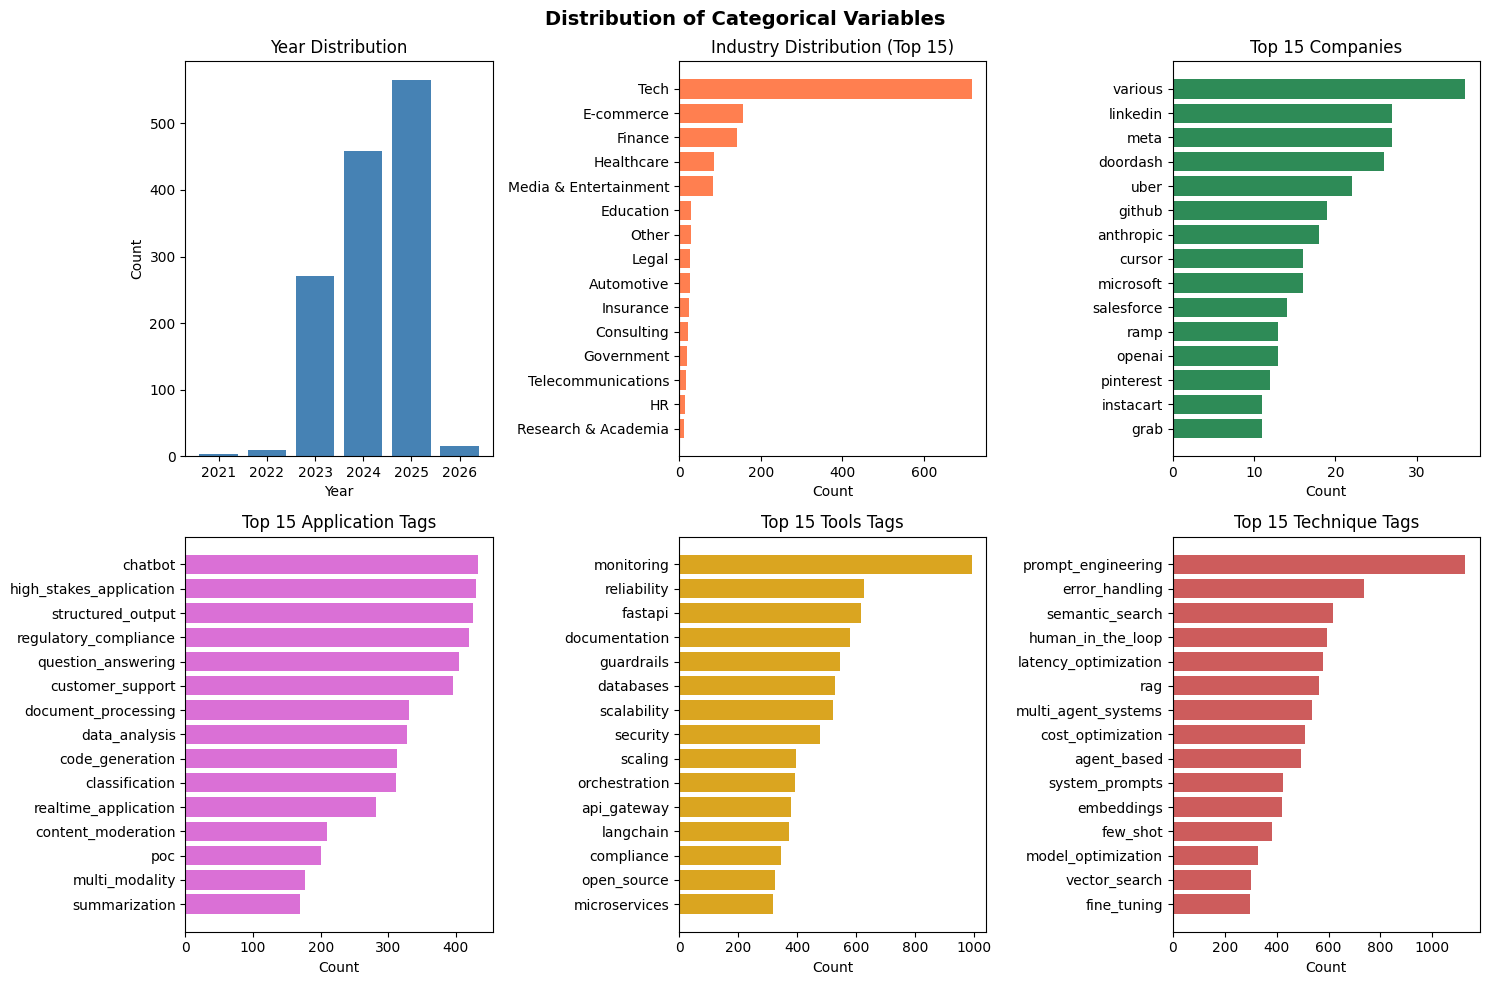

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Distribution of Categorical Variables", fontsize=14, fontweight='bold')

# Year distribution
year_counts = df.filter(pl.col("year").is_not_null()).group_by("year").len().sort("year")
axes[0, 0].bar(year_counts["year"].to_list(), year_counts["len"].to_list(), color='steelblue')
axes[0, 0].set_title("Year Distribution")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("Count")

# Industry distribution (top 10)
industry_counts = df.group_by("industry").len().sort("len", descending=True).head(15)
axes[0, 1].barh(industry_counts["industry"].to_list()[::-1], industry_counts["len"].to_list()[::-1], color='coral')
axes[0, 1].set_title("Industry Distribution (Top 15)")
axes[0, 1].set_xlabel("Count")

# Company distribution (top 15)
company_counts = df.group_by("company").len().sort("len", descending=True).head(15)
axes[0, 2].barh(company_counts["company"].to_list()[::-1], company_counts["len"].to_list()[::-1], color='seagreen')
axes[0, 2].set_title("Top 15 Companies")
axes[0, 2].set_xlabel("Count")

# Application tags distribution
app_tags = df.select(pl.col("application_tags").str.split(",").explode().str.strip_chars()).to_series().value_counts().sort("count", descending=True).head(15)
axes[1, 0].barh(app_tags["application_tags"].to_list()[::-1], app_tags["count"].to_list()[::-1], color='orchid')
axes[1, 0].set_title("Top 15 Application Tags")
axes[1, 0].set_xlabel("Count")

# Tools tags distribution
tools_tags = df.select(pl.col("tools_tags").str.split(",").explode().str.strip_chars()).to_series().value_counts().sort("count", descending=True).head(15)
axes[1, 1].barh(tools_tags["tools_tags"].to_list()[::-1], tools_tags["count"].to_list()[::-1], color='goldenrod')
axes[1, 1].set_title("Top 15 Tools Tags")
axes[1, 1].set_xlabel("Count")

# Techniques tags distribution
tech_tags = df.select(pl.col("techniques_tags").str.split(",").explode().str.strip_chars()).to_series().value_counts().sort("count", descending=True).head(15)
axes[1, 2].barh(tech_tags["techniques_tags"].to_list()[::-1], tech_tags["count"].to_list()[::-1], color='indianred')
axes[1, 2].set_title("Top 15 Technique Tags")
axes[1, 2].set_xlabel("Count")

plt.tight_layout()
plt.show()

**Finding:** Distribution insights for newsletter design:
- **Year**: 2024-2025 dominate (recent, relevant content)
- **Industry**: Tech overwhelmingly dominant; E-commerce, Finance, Healthcare follow
- **Companies**: "various" and major tech (LinkedIn, Meta, DoorDash, Uber) lead
- **Applications**: Chatbots, high-stakes apps, structured output are top use cases
- **Tools**: Monitoring, reliability, FastAPI most common
- **Techniques**: Prompt engineering, error handling, semantic search lead

**Recommendation:** Consider industry-based or technique-based newsletter sections.

## Weekly Distribution Analysis

Analyze news items by week to understand the temporal distribution and identify gaps.

In [5]:
# Parse created_at and extract week information
df_weekly = df.with_columns([
    pl.col("created_at").str.to_datetime("%Y-%m-%dT%H:%M:%S%.3fZ").alias("created_dt")
]).with_columns([
    pl.col("created_dt").dt.year().alias("dt_year"),
    pl.col("created_dt").dt.week().alias("dt_week"),
    pl.col("created_dt").dt.strftime("%Y-W%W").alias("year_week")
])

# Count items per week
weekly_counts = (
    df_weekly
    .group_by("year_week")
    .agg(pl.len().alias("count"))
    .sort("year_week")
)

print(f"Total weeks with data: {weekly_counts.height}")
print(f"\nWeekly item count statistics:")
print(f"  Min: {weekly_counts['count'].min()}")
print(f"  Max: {weekly_counts['count'].max()}")
print(f"  Mean: {weekly_counts['count'].mean():.1f}")
print(f"  Median: {weekly_counts['count'].median()}")

# Show first and last weeks
print(f"\nDate range: {df_weekly['created_dt'].min()} to {df_weekly['created_dt'].max()}")
print(f"\nFirst 5 weeks:\n{weekly_counts.head(5)}")
print(f"\nLast 5 weeks:\n{weekly_counts.tail(5)}")

Total weeks with data: 62

Weekly item count statistics:
  Min: 1
  Max: 186
  Mean: 22.9
  Median: 14.0

Date range: 2024-07-10 14:21:00 to 2026-01-15 12:43:00

First 5 weeks:
shape: (5, 2)
┌───────────┬───────┐
│ year_week ┆ count │
│ ---       ┆ ---   │
│ str       ┆ u32   │
╞═══════════╪═══════╡
│ 2024-W28  ┆ 5     │
│ 2024-W31  ┆ 58    │
│ 2024-W32  ┆ 1     │
│ 2024-W34  ┆ 1     │
│ 2024-W45  ┆ 38    │
└───────────┴───────┘

Last 5 weeks:
shape: (5, 2)
┌───────────┬───────┐
│ year_week ┆ count │
│ ---       ┆ ---   │
│ str       ┆ u32   │
╞═══════════╪═══════╡
│ 2025-W51  ┆ 186   │
│ 2025-W52  ┆ 7     │
│ 2026-W00  ┆ 2     │
│ 2026-W01  ┆ 5     │
│ 2026-W02  ┆ 16    │
└───────────┴───────┘


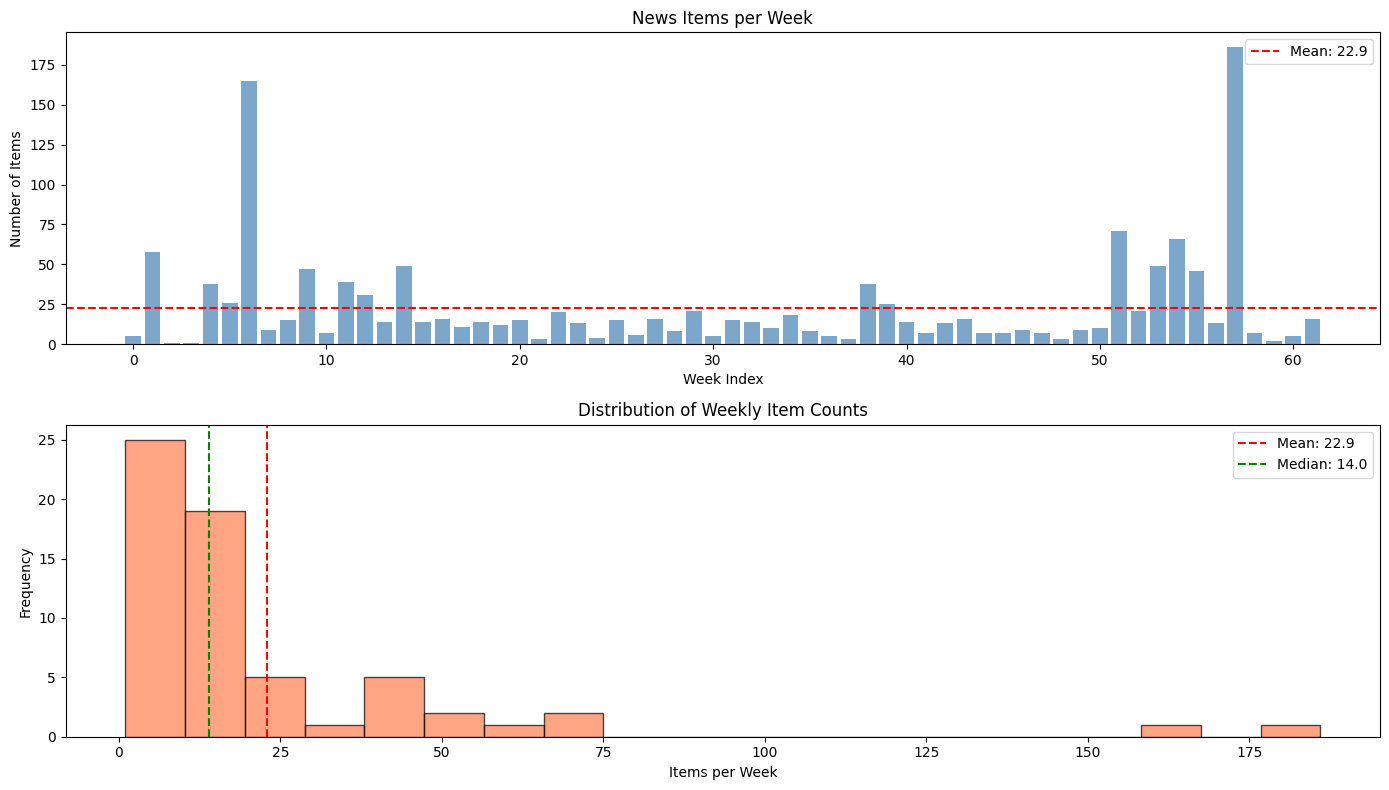


Checking for gaps in weekly data...
Date range: 2024-07-10 14:21:00 to 2026-01-15 12:43:00


In [6]:
# Visualize weekly distribution
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Bar chart of weekly counts
ax1 = axes[0]
weeks = weekly_counts["year_week"].to_list()
counts = weekly_counts["count"].to_list()
ax1.bar(range(len(weeks)), counts, color='steelblue', alpha=0.7)
ax1.set_xlabel("Week Index")
ax1.set_ylabel("Number of Items")
ax1.set_title("News Items per Week")
ax1.axhline(y=weekly_counts['count'].mean(), color='red', linestyle='--', label=f'Mean: {weekly_counts["count"].mean():.1f}')
ax1.legend()

# Histogram of weekly counts
ax2 = axes[1]
ax2.hist(counts, bins=20, color='coral', edgecolor='black', alpha=0.7)
ax2.set_xlabel("Items per Week")
ax2.set_ylabel("Frequency")
ax2.set_title("Distribution of Weekly Item Counts")
ax2.axvline(x=weekly_counts['count'].mean(), color='red', linestyle='--', label=f'Mean: {weekly_counts["count"].mean():.1f}')
ax2.axvline(x=weekly_counts['count'].median(), color='green', linestyle='--', label=f'Median: {weekly_counts["count"].median()}')
ax2.legend()

plt.tight_layout()
plt.show()

# Check for empty weeks (gaps in sequence)
print("\n" + "="*50)
print("Checking for gaps in weekly data...")
# Get all weeks in the date range
min_date = df_weekly['created_dt'].min()
max_date = df_weekly['created_dt'].max()
print(f"Date range: {min_date} to {max_date}")

**Finding:** Weekly distribution is highly variable:
- **62 weeks** with data, but coverage is uneven
- Some weeks have 1-5 items, others have 100+ (likely batch imports)
- **Median: 14 items/week** - reasonable for a curated newsletter
- Date range spans July 2024 to January 2026

**Implication:** Need to handle weeks with few items gracefully. Consider combining sparse weeks or adjusting expectations.

## Text Length Distribution

Analyze the length of titles, short summaries, and full summaries to understand the content structure.

In [7]:
# Calculate text lengths (in characters and words)
df_lengths = df.with_columns([
    pl.col("title").str.len_chars().alias("title_chars"),
    pl.col("title").str.split(" ").list.len().alias("title_words"),
    pl.col("short_summary").str.len_chars().alias("short_summary_chars"),
    pl.col("short_summary").str.split(" ").list.len().alias("short_summary_words"),
    pl.col("full_summary").str.len_chars().alias("full_summary_chars"),
    pl.col("full_summary").str.split(" ").list.len().alias("full_summary_words"),
])

# Print statistics
print("Text Length Statistics (Characters):")
print("=" * 60)
for col in ["title_chars", "short_summary_chars", "full_summary_chars"]:
    data = df_lengths[col]
    print(f"\n{col.replace('_chars', '').replace('_', ' ').title()}:")
    print(f"  Min: {data.min():,} | Max: {data.max():,} | Mean: {data.mean():,.0f} | Median: {data.median():,.0f}")

print("\n" + "=" * 60)
print("Text Length Statistics (Words):")
print("=" * 60)
for col in ["title_words", "short_summary_words", "full_summary_words"]:
    data = df_lengths[col]
    print(f"\n{col.replace('_words', '').replace('_', ' ').title()}:")
    print(f"  Min: {data.min():,} | Max: {data.max():,} | Mean: {data.mean():,.0f} | Median: {data.median():,.0f}")

Text Length Statistics (Characters):

Title:
  Min: 0 | Max: 123 | Mean: 69 | Median: 68

Short Summary:
  Min: 0 | Max: 1,280 | Mean: 805 | Median: 802

Full Summary:
  Min: 100 | Max: 47,149 | Mean: 13,656 | Median: 11,530

Text Length Statistics (Words):

Title:
  Min: 1 | Max: 15 | Mean: 9 | Median: 9

Short Summary:
  Min: 1 | Max: 190 | Mean: 107 | Median: 107

Full Summary:
  Min: 11 | Max: 6,545 | Mean: 1,798 | Median: 1,523


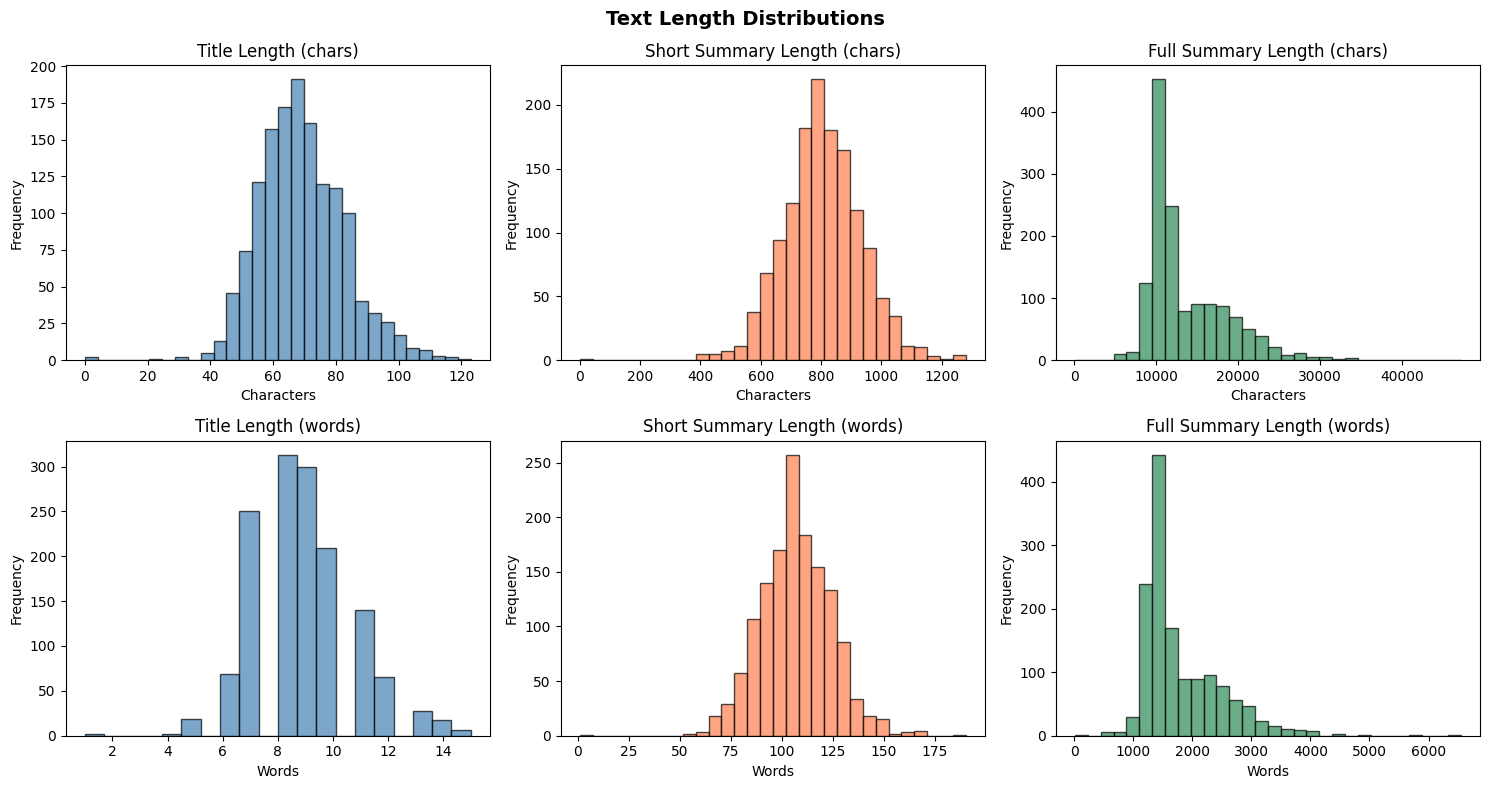

In [8]:
# Visualize text length distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Text Length Distributions", fontsize=14, fontweight='bold')

# Character lengths
axes[0, 0].hist(df_lengths["title_chars"].to_list(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel("Characters")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].set_title("Title Length (chars)")

axes[0, 1].hist(df_lengths["short_summary_chars"].to_list(), bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel("Characters")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].set_title("Short Summary Length (chars)")

axes[0, 2].hist(df_lengths["full_summary_chars"].to_list(), bins=30, color='seagreen', edgecolor='black', alpha=0.7)
axes[0, 2].set_xlabel("Characters")
axes[0, 2].set_ylabel("Frequency")
axes[0, 2].set_title("Full Summary Length (chars)")

# Word counts
axes[1, 0].hist(df_lengths["title_words"].to_list(), bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel("Words")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].set_title("Title Length (words)")

axes[1, 1].hist(df_lengths["short_summary_words"].to_list(), bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel("Words")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].set_title("Short Summary Length (words)")

axes[1, 2].hist(df_lengths["full_summary_words"].to_list(), bins=30, color='seagreen', edgecolor='black', alpha=0.7)
axes[1, 2].set_xlabel("Words")
axes[1, 2].set_ylabel("Frequency")
axes[1, 2].set_title("Full Summary Length (words)")

plt.tight_layout()
plt.show()

**Finding:** Text length analysis for content strategy:

| Field | Median (chars) | Median (words) | Use Case |
|-------|----------------|----------------|----------|
| **Title** | 68 | 9 | Headlines - perfect as-is |
| **Short Summary** | 802 | 107 | Newsletter blurbs - use directly |
| **Full Summary** | 11,530 | 1,523 | Too long - avoid or heavily truncate |

**Recommendation:** Use `short_summary` directly for newsletter items. No need to call LLM for summarization unless we want to further condense or re-style.
